In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [5]:
df = pd.read_csv("merged_stock_sentiment_data.csv")
print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Adj Close      Close       High        Low       Open     Volume Company  \
0   8.532785  10.115357  10.135000   9.851786   9.860000  658677600   Apple   
1   8.712500   8.712500   8.897000   8.686500   8.816500   84050000  Amazon   
2   8.778500   8.778500   8.950000   8.679500   8.686000  116210000  Amazon   
3   8.887500   8.887500   8.987500   8.728000   8.843000   93130000  Amazon   
4  11.446334  13.569286  13.602857  13.282143  13.321429  467832400   Apple   

         Date  Target  Score  Comments  \
0  2010-09-20       1      0         0   
1  2010-12-13       1      7         5   
2  2010-12-15       1      8         0   
3  2011-02-24       1      5         1   
4  2011-09-12      -1      5        16   

                                        Cleaned_Text Sentiment  \
0                 stock market game iphone ipad play  Positive   
1                  hussman warning awful time invest   Neutral   
2      awful time invest reflection lost opportunity  Neg

In [7]:
if 'Date' in df.columns:
   df['Date'] = pd.to_datetime(df['Date'])
   df = df.sort_values(by='Date')
df.ffill(inplace=True)

,Adj Close,Close,High,Low,Open,Volume,Company,Date,Target,Score,Comments,Cleaned_Text,Sentiment,Sentiment_Score
0,8.532785,10.115357,10.135000,9.851786,9.860000,658677600,Apple,2010-09-20,1,0,0,stock market game iphone ipad play,Positive,0.999895
1,8.712500,8.712500,8.897000,8.686500,8.816500,84050000,Amazon,2010-12-13,1,7,5,hussman warning awful time invest,Neutral,0.553402
2,8.778500,8.778500,8.950000,8.679500,8.686000,116210000,Amazon,2010-12-15,1,8,0,awful time invest reflection lost opportunity,Negative,0.982149
3,8.887500,8.887500,8.987500,8.728000,8.843000,93130000,Amazon,2011-02-24,1,5,1,amazon prime streaming disrupt netflix,Negative,0.977377
4,11.446334,13.569286,13.602857,13.282143,13.321429,467832400,Apple,2011-09-12,-1,5,16,personally im fan theyre already beatendown pr...,Negative,0.993987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12064,205.740005,205.740005,207.639999,205.050003,206.979996,28061600,Amazon,2024-11-27,1,0,23,im taking hard look spending got thinking amaz...,Positive,0.999907
12065,205.740005,205.740005,207.639999,205.050003,206.979996,28061600,Amazon,2024-11-27,1,31,307,please use thread discussion dont feel warrant...,Positive,0.999910
12067,237.330002,237.330002,237.809998,233.970001,234.809998,28481400,Apple,2024-11-29,0,0,2,hey anybody made purchase apple paid time chas...,Positive,0.998584
12066,207.889999,207.889999,208.199997,204.589996,205.830002,24892400,Amazon,2024-11-29,1,0,35,previously compared portfolio strategist inves...,Positive,0.999987


In [8]:
if 'Sentiment' in df.columns:
   df['Sentiment'] = df['Sentiment'].map({
         'Positive': 1,
         'Negative': -1,
         'Neutral': 0
    })
non_numeric = df.select_dtypes(include='object').columns
df.drop(columns=non_numeric, inplace=True)
df.fillna(0, inplace=True)

C:\Users\Lokesh Reddy\AppData\Local\Temp\ipykernel_29536\769600133.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_numeric = df.select_dtypes(include='object').columns


,Adj Close,Close,High,Low,Open,Volume,Date,Target,Score,Comments,Sentiment,Sentiment_Score
0,8.532785,10.115357,10.135000,9.851786,9.860000,658677600,2010-09-20,1,0,0,1,0.999895
1,8.712500,8.712500,8.897000,8.686500,8.816500,84050000,2010-12-13,1,7,5,0,0.553402
2,8.778500,8.778500,8.950000,8.679500,8.686000,116210000,2010-12-15,1,8,0,-1,0.982149
3,8.887500,8.887500,8.987500,8.728000,8.843000,93130000,2011-02-24,1,5,1,-1,0.977377
4,11.446334,13.569286,13.602857,13.282143,13.321429,467832400,2011-09-12,-1,5,16,-1,0.993987
...,...,...,...,...,...,...,...,...,...,...,...,...
12064,205.740005,205.740005,207.639999,205.050003,206.979996,28061600,2024-11-27,1,0,23,1,0.999907
12065,205.740005,205.740005,207.639999,205.050003,206.979996,28061600,2024-11-27,1,31,307,1,0.999910
12067,237.330002,237.330002,237.809998,233.970001,234.809998,28481400,2024-11-29,0,0,2,1,0.998584
12066,207.889999,207.889999,208.199997,204.589996,205.830002,24892400,2024-11-29,1,0,35,1,0.999987


In [10]:
df['Next_Close'] = df['Close'].shift(-1)
df.dropna(inplace=True)
df['Market_Direction'] = np.where(df['Next_Close'] > df['Close'], 1, 0)
features = ['Open', 'High', 'Low', 'Close', 'Volume']
if 'Sentiment' in df.columns:
    features.append('Sentiment')
X = df[features]
y_price = df['Next_Close']
y_direction = df['Market_Direction']

In [11]:
X_train, X_test, y_train_price, y_test_price = train_test_split(
X, y_price, random_state=42
)
_, _, y_train_dir, y_test_dir = train_test_split(
    X, y_direction, random_state=42
)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train_price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred_price = model.predict(X_test)
y_pred_direction = np.where(y_pred_price > X_test['Close'], 1, 0)

In [14]:
mse = mean_squared_error(y_test_price, y_pred_price)
r2 = r2_score(y_test_price, y_pred_price)
print("\nRegression Performance:")
print("MSE:", mse)
print("R2 Score:", r2)
accuracy = accuracy_score(y_test_dir, y_pred_direction)
print("\nMarket Direction Accuracy:")
print("Accuracy:", accuracy)


Regression Performance:
MSE: 1909.0656621700148
R2 Score: 0.7259882933913926

Market Direction Accuracy:
Accuracy: 0.6045740802121312


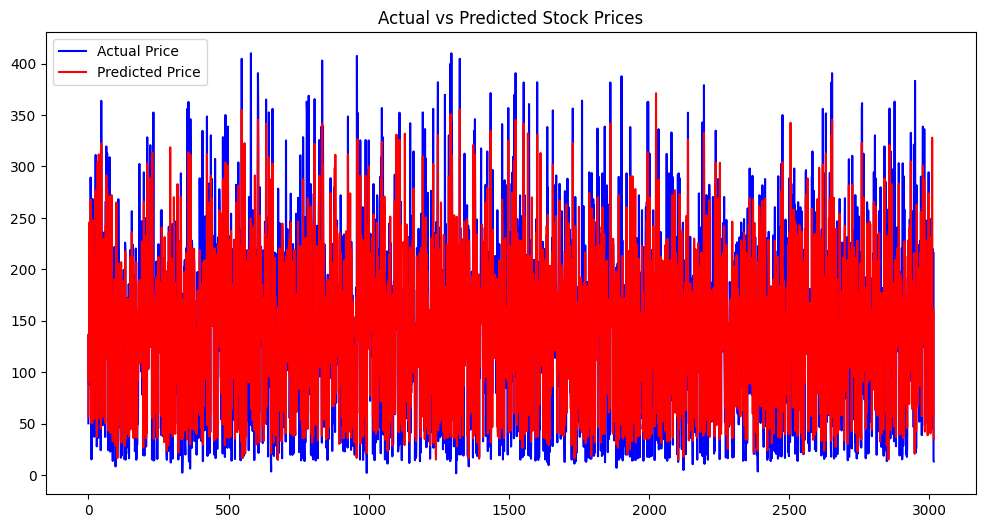

In [15]:
plt.figure(figsize=(12,6))
plt.plot(y_test_price.values, label='Actual Price', color='blue')
plt.plot(y_pred_price, label='Predicted Price', color='red')
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.show()


Feature Importance:
     Feature   Coefficient
0       Open -1.087088e-01
1       High -8.626819e-01
2        Low  1.212907e+00
3      Close  6.391260e-01
4     Volume -2.540898e-08
5  Sentiment -4.286623e-01


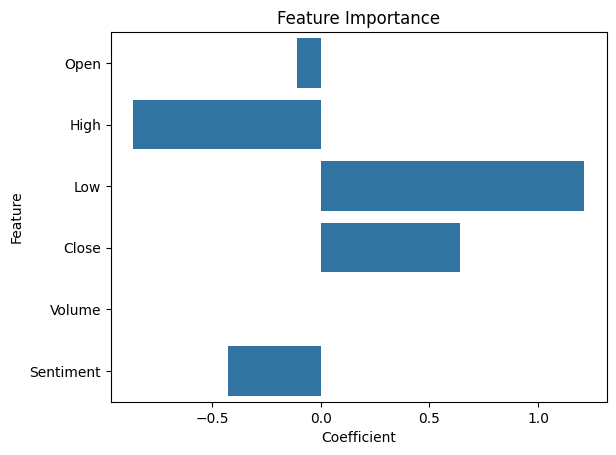

In [16]:
coefficients = pd.DataFrame({
'Feature': X.columns,
'Coefficient': model.coef_
})
print("\nFeature Importance:")
print(coefficients)
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title("Feature Importance")
plt.show()

In [18]:
last_row = X.iloc[-1:]
future_price = model.predict(last_row)[0]
print("\nNext Day Predicted Price:", future_price)
if future_price > df['Close'].iloc[-1]:
    print("Market Direction: UP 📈")
else:
    print("Market Direction: DOWN 📉")


Next Day Predicted Price: 203.4806329004804
Market Direction: DOWN 📉
